### Data Analysis and Visualisation of Household Heating Behaviour

This notebook explores eight months of smart home data collected from a single household. The dataset includes measurements from two temperature sensors (TA, TB) which record temperature and battery level, and two temperature-humidity sensors (HA, HB) which record temperature, humidity and battery level. Boiler status (on/off) is also recorded. Data from all sensors are sampled at 10-minute intervals. 

The aim of this analysis is to examine patterns in household energy use and to develop visualisations that help users understand whether their smart thermostat system is operating as expected. By making these patterns more accessible and interpretable, the visualisations can support more informed energy-related decisions and encourage sustainable household practices.

Dataset: Single household, March-October 2017, 10-minute sampling intervals. Provided as part of a university data visualisation module.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from pathlib import Path 

pd.set_option("display.max_columns", None)

# define the four temperature sensors
SENSOR_COLS = ["temperature_TA", "temperature_TB", "temperature_HA", "temperature_HB"]

In [2]:
DATA_PATH = Path("data") / "all_thermostat_data.csv"
df = pd.read_csv(DATA_PATH)

print(f"{df.shape[0]} rows x {df.shape[1]} columns")
df.head()

32420 rows x 12 columns


,timestamp,battery_TA,temperature_TA,battery_TB,temperature_TB,humidity_HA,battery_HA,temperature_HA,humidity_HB,battery_HB,temperature_HB,status_boiler
0,2017-03-05 21:00:00+00:00,2.21,19.6,NaN,19.5,63.4,3.74,20.5,64.6,3.74,23.1,OFF
1,2017-03-05 21:10:00+00:00,2.21,19.6,2.84,19.5,66.7,3.74,20.4,66.8,3.74,23.2,OFF
2,2017-03-05 21:20:00+00:00,2.21,19.5,2.84,19.5,68.4,3.74,20.4,66.8,3.74,23.3,OFF
3,2017-03-05 21:30:00+00:00,2.21,19.5,2.84,19.4,69.6,3.74,20.4,66.8,3.74,23.4,OFF
4,2017-03-05 21:40:00+00:00,2.21,19.6,2.84,19.4,69.5,3.74,20.4,67.7,3.74,23.4,OFF


##### Prepare Data & Quality Check

First, `timestamp` column is converted to a dataframe format and the dataset is sorted chronologically. Basic data quality checks are then performed to assess the size of the dataset, verify that observations are recorded at regular 10-minute intervals, determine the temporal coverage and identify any missing values.

In [3]:
# parse timestamp and sort dates in a chronological order
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)

# check how much data and if evenly spaced
span = df["timestamp"].max() - df["timestamp"].min()
gaps = df["timestamp"].diff().dropna()

print(f"Period: {df['timestamp'].min():%d-%m-%Y} to {df['timestamp'].max():%d-%m-%Y} ({span.days} days)")
print(f"Reading interval: {gaps.mode().iloc[0]} (constant: {gaps.nunique() == 1})")
print(f"Missing values: {int(df.isna().sum().sum())}")

Period: 05-03-2017 to 17-10-2017 (225 days)
Reading interval: 0 days 00:10:00 (constant: True)
Missing values: 1


The dataset is in good condition, with only one missing value detected. Given its minor impact, this has no effect on the analysis and no additional preprocessing is required.

##### Exploratory Data Analysis: Boiler Status & Heating Events

The `status_boiler` variable records whether the boiler is `ON` or `OFF` at each 10-minute interval. While this provides information about the boiler's state at individual time points, it does not directly describe heating activity. To analyse heating behaviour, consecutive `ON` observations are grouped into discrete heating events, allowing the frequency and duration of boiler operation to be examined.

In [4]:
# boolean flag
df["boiler_on"] = (df["status_boiler"] == "ON").astype(int)

# every run of identical states is given its own id; id increments each time
# the boiler flips between ON and OFF; Consecutive ON readings share an id
block_id = df["boiler_on"].ne(df["boiler_on"].shift()).cumsum()

# group each ON run into a single event
events = (
    df[df["boiler_on"] == 1]
    .groupby(block_id)
    .agg(start=("timestamp", "first"), readings=("timestamp", "size"))
    .reset_index(drop=True)
)
events["duration_min"] = events["readings"] * 10    # each reading = 10min window

print(f"Heating events: {len(events)}")
print(f"Average duration: {events['duration_min'].mean():.0f} min")
print(f"Longest: {events['duration_min'].max():.0f} min, Shortest: {events['duration_min'].max():.0f} min")
print(f"Total time heating: {events['duration_min'].sum() / 60:.0f} hours across the period")

Heating events: 42
Average duration: 55 min
Longest: 450 min, Shortest: 450 min
Total time heating: 39 hours across the period


##### Data Visualisations

The dataset contains measurements from four temperature sensors, each recording approximately 32,000 observations over the eight-month period. Displaying all measurements simultaneously on a single chart would result in substantial visual clutter and make patterns difficult to interpret. The visualisations presented below therefore explore different approaches to representing the data, with each designed to address specific visualisation challenges and improve interpretability.

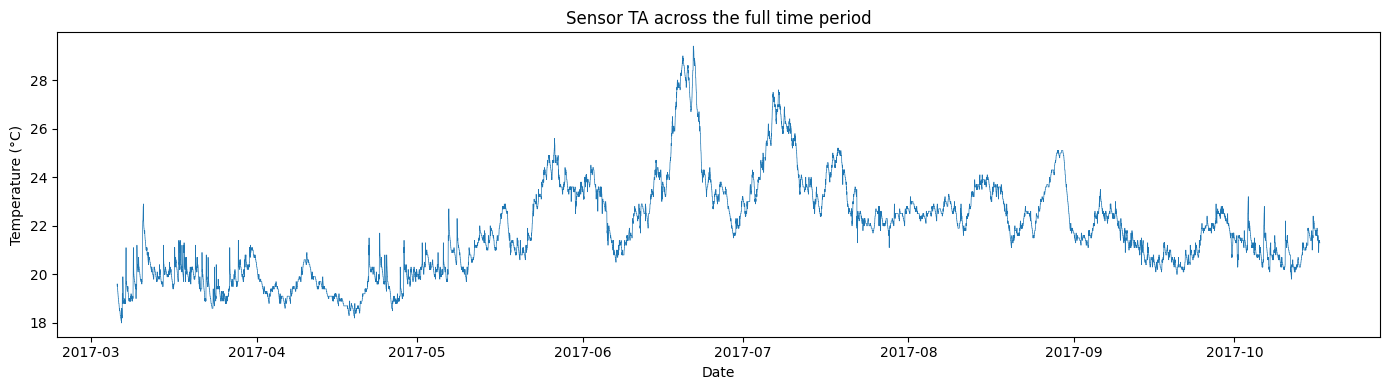

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["timestamp"], df["temperature_TA"], linewidth=0.5, color="#1f77b4")
ax.set_title("Sensor TA across the full time period")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

The seasonal pattern is clearly visible, with higher temperatures during the summer months and lower temperatures during the colder periods. However, this represents data from a single sensor and therefore only reflects conditions in one room. To obtain a more complete understanding of the household's thermal environment, data from all four sensors must be considered and visualised together. 

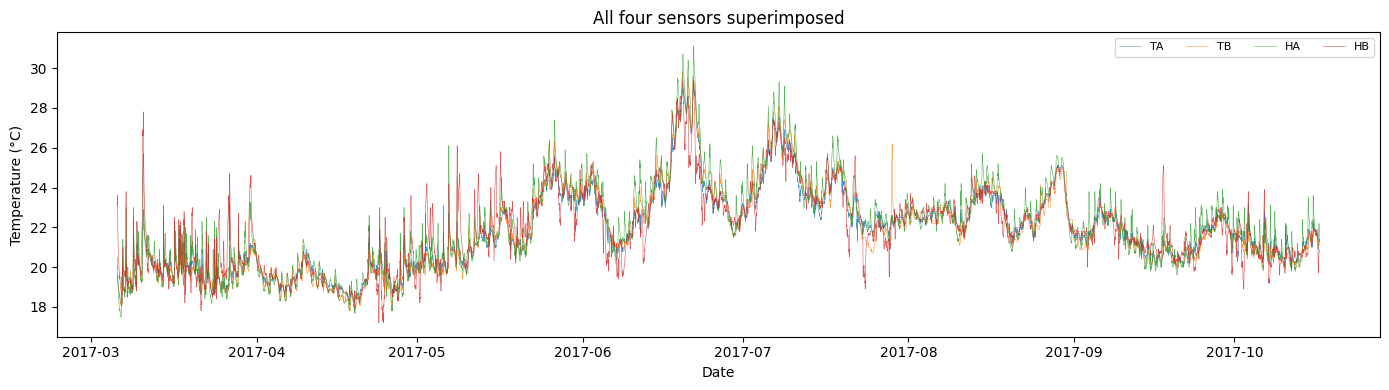

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
for col in SENSOR_COLS:
    ax.plot(df["timestamp"], df[col], linewidth=0.4, alpha=0.8, label=col.replace("temperature_", ""))
ax.set_title("All four sensors superimposed")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

This is not an effective visualisation. Although the four sensors exhibit similar patterns, their overlapping time series result in overplotting, collapsing into a single indistinguishable band. As a consequence, it becomes difficult to follow individual room-level trajectories. While a legend is provided to map colours to sensors, the visual overlap makes these distinctions untraceable within the plot. Overall, the high data density on a single set of axes reduces readability and limits the interpretability of the figure.

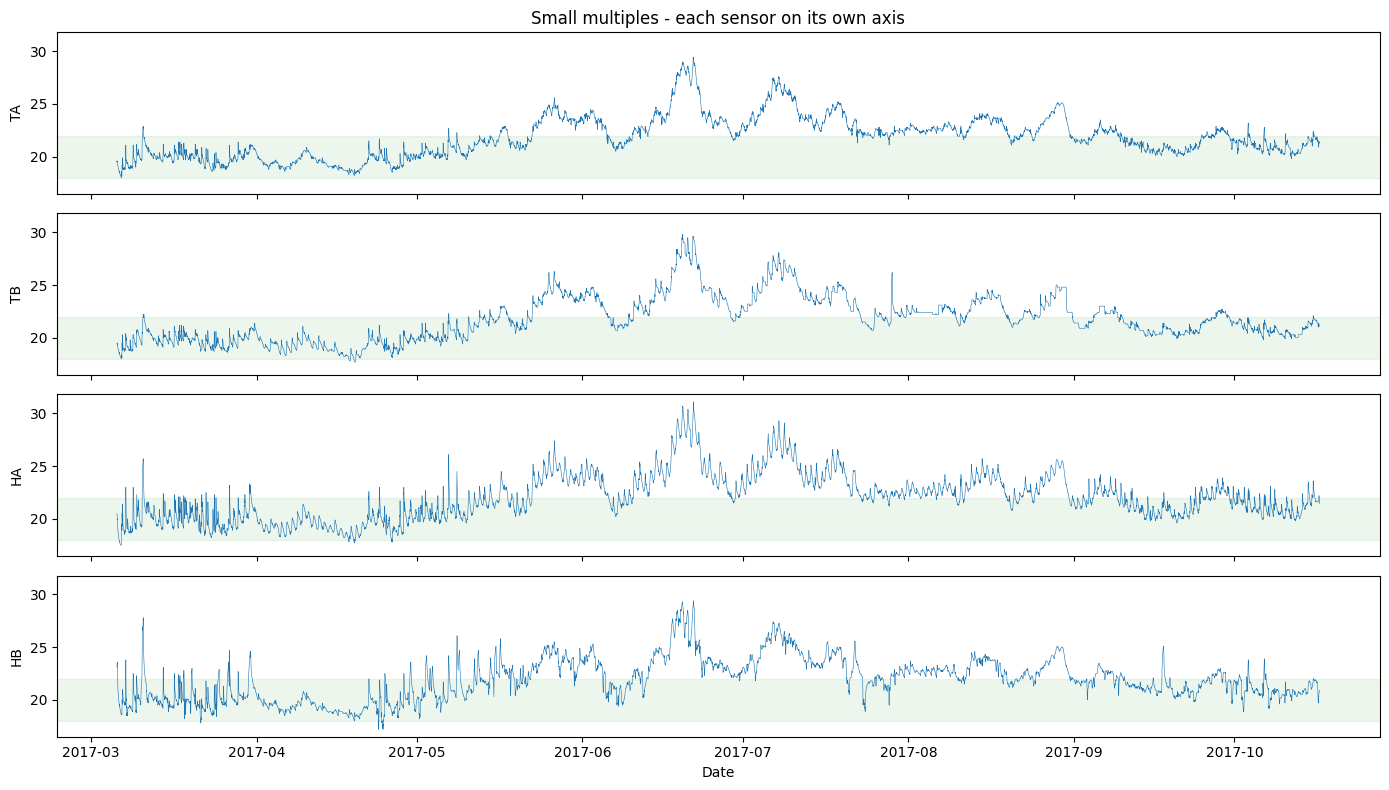

In [7]:
fig, axes = plt.subplots(len(SENSOR_COLS), 1, figsize=(14, 8), sharex=True, sharey=True)

for ax, col in zip(axes, SENSOR_COLS):
    ax.plot(df["timestamp"], df[col], linewidth=0.4, color="#1f77b4")
    ax.axhspan(18, 22, color="green", alpha=0.07)   # comfort band 18-22°C
    ax.set_ylabel(col.replace("temperature_", ""))

axes[0].set_title("Small multiples - each sensor on its own axis")
axes[-1].set_xlabel("Date")
fig.tight_layout()
plt.show()

Providing each sensor with its own panel (small multiples) preserves the legibility of individual room trajectories, while shared x- and y-axes ensure that the panels remain directly comparable. The shaded band indicates the 18-22°C comfort range, offering a consistent reference across all subplots.

However, this approach introduces a trade-off: small multiples require more vertical space, and it becomes more difficult to precisely compare temperature differences between rooms at a single point in time than it would be on a shared-axis plot.

##### Heating Effort vs Indoor Comfort

If the boiler is operating effectively, its workload would be expected to vary seasonally, increasing during colder months and decreasing during warmer periods. However, the key question is whether indoor temperatures vary in parallel with this heating effort, or whether the system maintains relatively stable comfort conditions while the boiler compensates for external temperature changes.

In [8]:
# heating events per month
events["month"] = events["start"].dt.tz_convert(None).dt.to_period("M")

# mean indoor temperature per month (average across the four sensors)
df["avg_temp"] = df[SENSOR_COLS].mean(axis=1)
df["month"] = df["timestamp"].dt.tz_convert(None).dt.to_period("M")

monthly = pd.DataFrame({
    "events": events.groupby("month").size(),
    "avg_temp": df.groupby("month")["avg_temp"].mean(),
})
monthly["events"] = monthly["events"].fillna(0).astype(int) 
monthly.index = monthly.index.astype(str)
monthly

,events,avg_temp
month,,
2017-03,25,19.996272
2017-04,11,19.371910
2017-05,4,22.041655
2017-06,0,23.864288
2017-07,0,23.798129
2017-08,0,22.910316
2017-09,0,21.468374
2017-10,2,20.988606


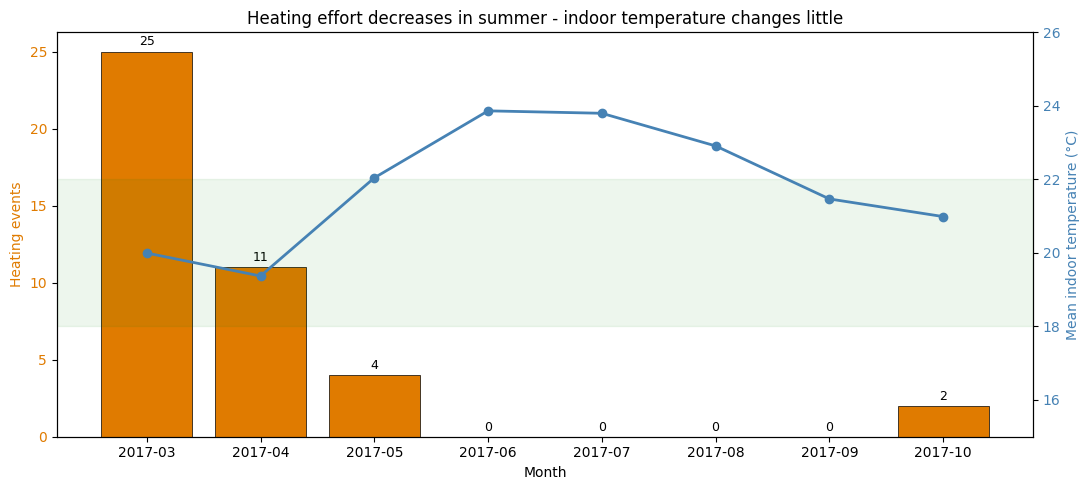

In [9]:
fig, ax1 = plt.subplots(figsize=(11, 5))

# left axis - heating effor (bars)
ax1.bar(monthly.index, monthly["events"],
        color="#e07b00", edgecolor="black", linewidth=0.5, label="Heating events")
ax1.set_xlabel("Month")
ax1.set_ylabel("Heating events", color="#e07b00")
ax1.tick_params(axis="y", labelcolor="#e07b00")

for x, v in zip(monthly.index, monthly["events"]):
    ax1.text(x, v + 0.4, str(v), ha="center", fontsize=9)

# right axis - indoor comfort (line)
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["avg_temp"],
         color="steelblue", marker="o", linewidth=2, label="Mean indoor temp")
ax2.axhspan(18, 22, color="green", alpha=0.07) # comfort band
ax2.set_ylim(15, 26)
ax2.set_ylabel("Mean indoor temperature (°C)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

ax1.set_title("Heating effort decreases in summer - indoor temperature changes little")
fig.tight_layout()
plt.show()

The contrast is clear. The boiler is active 25 times in March and not at all between June and September, yet indoor temperature remains within a relatively narrow range of approximately 4–5°C. In fact, the highest indoor temperatures occur during the unheated summer months, while the lowest values are observed in March and April, when boiler activity is at its peak.

This suggests that heating primarily serves to offset heat losses rather than substantially increasing indoor temperature, whereas passive solar gains in summer contribute significantly to warming.

*Note: The use of dual y-axes with independent scales can create the impression of a relationship where none exists. For this reason, the two variables should be interpreted as parallel but separate observations rather than evidence of correlation. The design is intentional, emphasising contrast between heating effort and thermal outcome.*

##### Weekly & Daily Patterns

The seasonal view conceals the finer structure of how heating is actually used. A closer examination reveals two additional perspectives: a single week, where individual heating bursts become visible, and the distribution of events across hours of the day, which provides insight into the household’s daily routine and usage patterns.

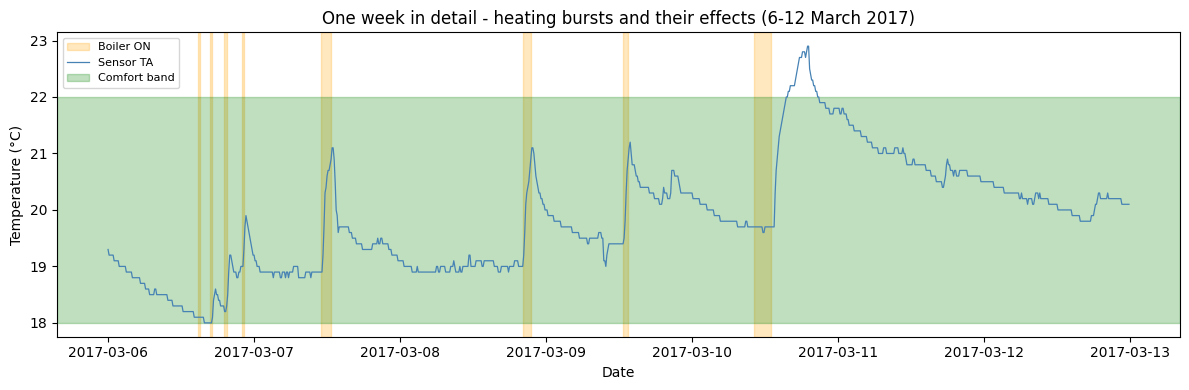

In [10]:
DETAILED_START = pd.Timestamp("2017-03-06", tz="UTC")
DETAILED_END = pd.Timestamp("2017-03-13", tz="UTC")
detailed_view = df[(df["timestamp"] >= DETAILED_START) & (df["timestamp"] < DETAILED_END)]

fig, ax = plt.subplots(figsize=(12, 4))

# shade the periods the boiler was ON, full height of the plot
ax.fill_between(detailed_view["timestamp"], 0, 1, where=detailed_view["boiler_on"] == 1,
                transform=ax.get_xaxis_transform(),
                color="orange", alpha=0.25, label="Boiler ON")

ax.plot(detailed_view["timestamp"], detailed_view["temperature_TA"],
        color="steelblue", linewidth=0.9, label="Sensor TA")
ax.axhspan(18, 22, color="green", alpha=0.25, label="Comfort band")

ax.set_title("One week in detail - heating bursts and their effects (6-12 March 2017)")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

Over this week, the boiler activates eight times, while indoor temperature remains largely within the comfort band throughout, approximately 18–23°C.

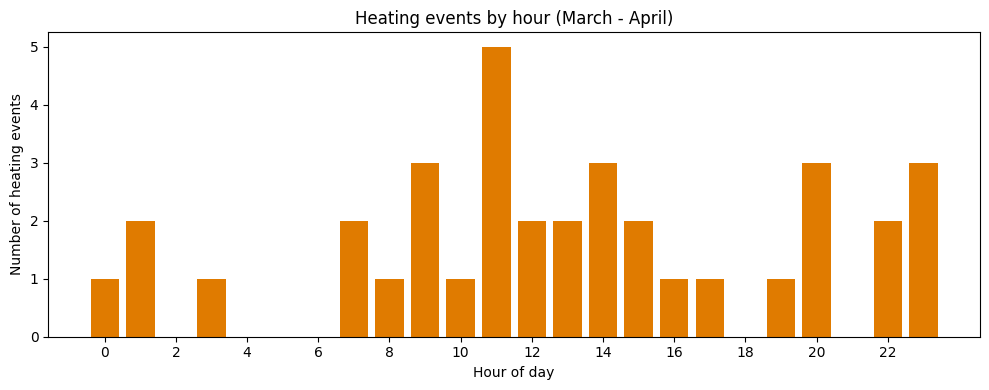

In [11]:
HEATING_START = pd.Timestamp("2017-03-01", tz="UTC")
HEATING_END = pd.Timestamp("2017-05-01", tz="UTC")

spring = events[(events["start"] >= HEATING_START) & (events["start"] < HEATING_END)].copy()
spring["hour"] = spring["start"].dt.hour
by_hour = spring.groupby("hour").size().reindex(range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_hour.index, by_hour.values, color="#e07b00")
ax.set_title("Heating events by hour (March - April)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of heating events")
ax.set_xticks(range(0, 24, 2))
fig.tight_layout()
plt.show()

There is a noticeable concentration of events around late morning (approximately 11:00h), with the remaining occurrences distributed across the afternoon and evening. However, over March–April there are only around 36 events in total, spread across the full 24-hour cycle. As a result, each bin is supported by only a small number of observations. While this suggests a potential pattern, the evidence is not strong enough to infer a consistent or fixed daily schedule.

##### Damp Risk & Room Balance

In addition to temperature and boiler status, the sensors provide two further signals of interest: humidity, which can serve as a proxy for dampness and mould risk, and the degree to which heat is evenly distributed across rooms.

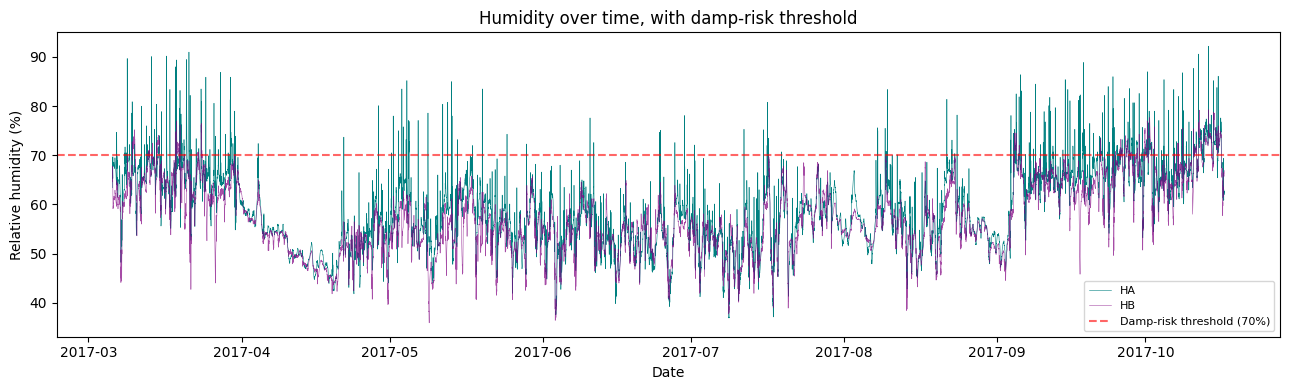

In [12]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["timestamp"], df["humidity_HA"], linewidth=0.4, color="teal", label="HA")
ax.plot(df["timestamp"], df["humidity_HB"], linewidth=0.4, color="purple", alpha=0.7, label="HB")
ax.axhline(70, color="red", linestyle="--", alpha=0.6, label="Damp-risk threshold (70%)")
ax.set_title("Humidity over time, with damp-risk threshold")
ax.set_xlabel("Date")
ax.set_ylabel("Relative humidity (%)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Humidity follows a clear seasonal pattern, but the two rooms exhibit notably different behaviours. HB remains relatively moderate, peaking at around 79%, whereas HA is consistently more humid, exceeding the 70% threshold and reaching up to 92%. This difference is particularly significant, as it suggests that a specific room - likely a kitchen or bathroom - is contributing disproportionately to the household’s mould risk. Such spatial variation would be obscured by a single aggregated humidity value for the entire home.

Mean spread: 0.85°C
Median spread: 0.70°C
Max spread: 5.90°C


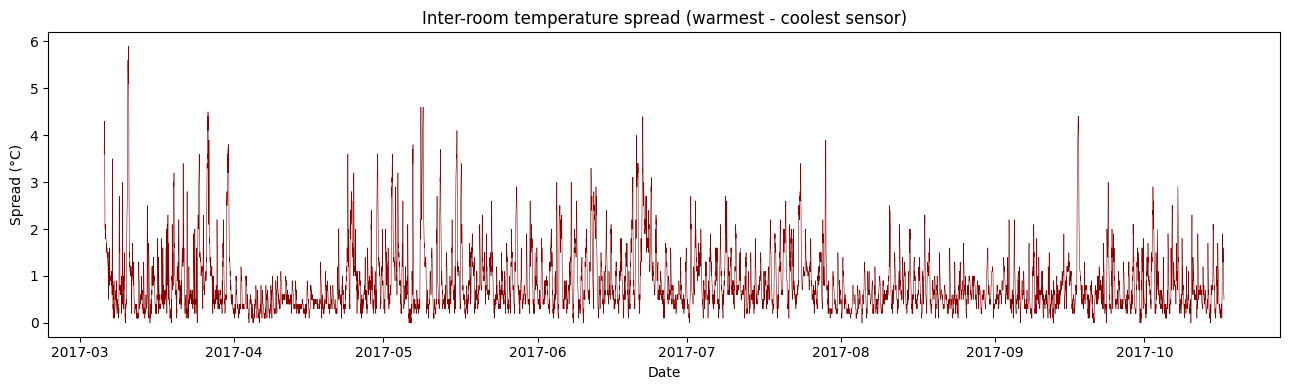

In [13]:
df["room_spread"] = df[SENSOR_COLS].max(axis=1) - df[SENSOR_COLS].min(axis=1)

print(f"Mean spread: {df['room_spread'].mean():.2f}°C")
print(f"Median spread: {df['room_spread'].median():.2f}°C")
print(f"Max spread: {df['room_spread'].max():.2f}°C")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["timestamp"], df["room_spread"], linewidth=0.4, color="darkred")
ax.set_title("Inter-room temperature spread (warmest - coolest sensor)")
ax.set_xlabel("Date")
ax.set_ylabel("Spread (°C)")
fig.tight_layout()
plt.show()

Most of the time, the household remains well balanced, with the four sensors typically staying within approximately 1°C of each other (mean spread: 0.85°C; median: 0.70°C). However, this alignment is occasionally disrupted, with the spread increasing to nearly 6°C. These spikes may warrant further investigation, as they could reflect transient conditions such as a door left open, localised solar gains, or uneven heat distribution leading to one room warming more rapidly than others.

##### Conclusion

- Heating effort is strongly seasonal, whereas indoor comfort is comparatively stable. Boiler activity drops from 25 events in March to none across the summer months, yet indoor temperature remains within an approximate 19–24°C range throughout the year.
- The home is warmest during unheated summer months, suggesting that passive solar gains provide much of the warming, while heating primarily acts to offset heat loss during colder periods rather than directly driving high indoor temperatures.
- Heating occurs in relatively short bursts (approximately 55 minutes each), totalling around 39 hours overall, with a weak tendency toward late-morning activation rather than a fixed daily schedule.
- Spatially, rooms are generally well balanced, typically within ~1°C of each other, although occasional deviations of up to 6°C indicate transient or localised effects.
- One room (HA) appears to carry a disproportionate share of humidity-related risk, frequently exceeding the 70% threshold and indicating a higher potential for damp conditions compared to the other sensor location.